In [6]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\Datasets\fuel_features.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27132 entries, 0 to 27131
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                --------------  ----- 
 0   country;"region";"income_level";"subsidy_level";"date";"petrol_usd_liter";"diesel_usd_liter";"brent_crude_usd";"tax_percentage";"brent_lag1";"brent_lag2";"brent_lag3";"brent_lag4";"petrol_lag1";"brent_wow_change"  27132 non-null  object
dtypes: object(1)
memory usage: 212.1+ KB


In [7]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\Datasets\fuel_features.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27132 entries, 0 to 27131
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           27132 non-null  object 
 1   region            27132 non-null  object 
 2   income_level      27132 non-null  object 
 3   subsidy_level     27132 non-null  object 
 4   date              27132 non-null  object 
 5   petrol_usd_liter  27132 non-null  float64
 6   diesel_usd_liter  27132 non-null  float64
 7   brent_crude_usd   27132 non-null  float64
 8   tax_percentage    27132 non-null  float64
 9   brent_lag1        27132 non-null  float64
 10  brent_lag2        27132 non-null  float64
 11  brent_lag3        27132 non-null  float64
 12  brent_lag4        27132 non-null  float64
 13  petrol_lag1       27132 non-null  float64
 14  brent_wow_change  27132 non-null  float64
dtypes: float64(10), object(5)
memory usage: 3.1+ MB


In [9]:
df['petrol_shift'] = df['petrol_usd_liter'] - df['petrol_lag1']
df[['country', 'date', 'petrol_lag1', 'petrol_usd_liter', 'petrol_shift']].head()

,country,date,petrol_lag1,petrol_usd_liter,petrol_shift
0,Algeria,2020-02-03,0.094,0.081,-0.013
1,Algeria,2020-02-10,0.081,0.070,-0.011
2,Algeria,2020-02-17,0.070,0.065,-0.005
3,Algeria,2020-02-24,0.065,0.113,0.048
4,Algeria,2020-03-02,0.113,0.106,-0.007


In [10]:
df['date'] = pd.to_datetime(df['date'])

cutoff_date = df['date'].quantile(0.8)

train = df[df['date'] <= cutoff_date]
test = df[df['date'] > cutoff_date]

print(train['date'].min(), train['date'].max())
print(test['date'].min(), test['date'].max())

2020-02-03 00:00:00 2025-01-13 00:00:00
2025-01-20 00:00:00 2026-04-06 00:00:00


In [11]:
features = ['brent_crude_usd', 'brent_lag1', 'brent_lag2', 'brent_lag3', 'brent_lag4',
            'brent_wow_change', 'subsidy_level', 'income_level', 'region']

X_train = train[features]
y_train = train['petrol_shift']

X_test = test[features]
y_test = test['petrol_shift']

X_train.head()

,brent_crude_usd,brent_lag1,brent_lag2,brent_lag3,brent_lag4,brent_wow_change,subsidy_level,income_level,region
0,68.44,68.79,66.51,65.54,65.75,-0.35,Very High,Middle,Africa
1,68.09,68.44,68.79,66.51,65.54,-0.35,Very High,Middle,Africa
2,70.46,68.09,68.44,68.79,66.51,2.37,Very High,Middle,Africa
3,71.61,70.46,68.09,68.44,68.79,1.15,Very High,Middle,Africa
4,70.53,71.61,70.46,68.09,68.44,-1.08,Very High,Middle,Africa


In [12]:
X_train_encoded = pd.get_dummies(X_train, columns=['subsidy_level', 'income_level', 'region'])
X_train_encoded.head()

,brent_crude_usd,brent_lag1,brent_lag2,brent_lag3,brent_lag4,brent_wow_change,subsidy_level_High,subsidy_level_Low,subsidy_level_Medium,subsidy_level_Very High,income_level_High,income_level_Low,income_level_Middle,region_Africa,region_Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America
0,68.44,68.79,66.51,65.54,65.75,-0.35,False,False,False,True,False,False,True,True,False,False,False,False,False,False
1,68.09,68.44,68.79,66.51,65.54,-0.35,False,False,False,True,False,False,True,True,False,False,False,False,False,False
2,70.46,68.09,68.44,68.79,66.51,2.37,False,False,False,True,False,False,True,True,False,False,False,False,False,False
3,71.61,70.46,68.09,68.44,68.79,1.15,False,False,False,True,False,False,True,True,False,False,False,False,False,False
4,70.53,71.61,70.46,68.09,68.44,-1.08,False,False,False,True,False,False,True,True,False,False,False,False,False,False


In [15]:
X_test_encoded = pd.get_dummies(X_test, columns=['subsidy_level', 'income_level', 'region'])

# force X_test_encoded to have exactly the same columns as X_train_encoded
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [16]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(21756, 20)
(5376, 20)


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
model.fit(X_train_encoded, y_train)

print("Model trained")

Model trained


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test_encoded)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

naive_mae = mean_absolute_error(y_test, np.zeros(len(y_test)))

print(f"Model MAE:  {mae:.4f}")
print(f"Naive MAE (guessing 'no change'): {naive_mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

Model MAE:  0.0236
Naive MAE (guessing 'no change'): 0.0345
RMSE: 0.0297
R2:   0.6049


In [20]:
importances = pd.Series(model.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
importances.head(8)

brent_wow_change           0.742703
subsidy_level_Low          0.159677
income_level_High          0.046668
region_Europe              0.018143
subsidy_level_Very High    0.014099
subsidy_level_Medium       0.013073
subsidy_level_High         0.002041
region_North America       0.000688
dtype: float64

In [21]:
test_results = test.copy()
test_results['predicted_shift'] = pred
test_results['predicted_price'] = test_results['petrol_lag1'] + test_results['predicted_shift']

test_results[['country', 'date', 'petrol_usd_liter', 'predicted_price']].head()

,country,date,petrol_usd_liter,predicted_price
259,Algeria,2025-01-20,0.182,0.166934
260,Algeria,2025-01-27,0.117,0.181221
261,Algeria,2025-02-03,0.147,0.104775
262,Algeria,2025-02-10,0.165,0.154956
263,Algeria,2025-02-17,0.185,0.157059


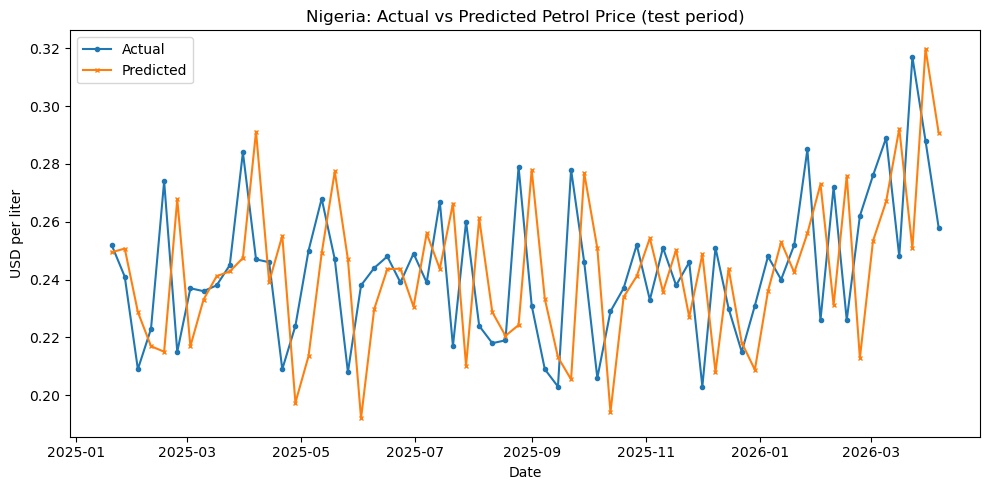

In [22]:
import matplotlib.pyplot as plt

nigeria = test_results[test_results['country'] == 'Nigeria'].sort_values('date')

plt.figure(figsize=(10, 5))
plt.plot(nigeria['date'], nigeria['petrol_usd_liter'], label='Actual', marker='o', markersize=3)
plt.plot(nigeria['date'], nigeria['predicted_price'], label='Predicted', marker='x', markersize=3)
plt.title('Nigeria: Actual vs Predicted Petrol Price (test period)')
plt.xlabel('Date')
plt.ylabel('USD per liter')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
test_results[['country', 'region', 'income_level', 'subsidy_level', 'date',
              'petrol_usd_liter', 'predicted_price', 'brent_crude_usd']].to_csv(
    r'C:\Users\DELL\Downloads\Datasets\forecast_results.csv', index=False)

print("Saved forecast_results.csv")

Saved forecast_results.csv
